0. Run imports
1. Load data
2. Clean books and ratings
3. Merge df
4. EDA
5. Filter ratings/users/books
6. Build book_tags_named
7. Build ONE final genre_tags
8. Run Apriori ONCE
9. Run KNN
10. Evaluate KNN

Run imports

In [49]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from mlxtend.frequent_patterns import apriori, association_rules
from pathlib import Path

from sklearn.model_selection import train_test_split
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import confusion_matrix, accuracy_score
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.model_selection import StratifiedKFold, cross_val_score

Load data

In [50]:
DATA_DIR = Path("git-forked-database")

books_df = pd.read_csv(DATA_DIR / "books.csv")
book_tags_df = pd.read_csv(DATA_DIR / "book_tags.csv")
ratings_df = pd.read_csv(DATA_DIR / "ratings.csv")
tags_df = pd.read_csv(DATA_DIR / "tags.csv")
to_read_df = pd.read_csv(DATA_DIR / "to_read.csv")


In [51]:
# Quick print to make sure all df are csv are correctly read
print(books_df.head())
print(book_tags_df.head())
print(ratings_df.head())
print(tags_df.head())
print(to_read_df.head())

   book_id  goodreads_book_id  best_book_id  work_id  books_count       isbn  \
0        1            2767052       2767052  2792775          272  439023483   
1        2                  3             3  4640799          491  439554934   
2        3              41865         41865  3212258          226  316015849   
3        4               2657          2657  3275794          487   61120081   
4        5               4671          4671   245494         1356  743273567   

         isbn13                      authors  original_publication_year  \
0  9.780439e+12              Suzanne Collins                     2008.0   
1  9.780440e+12  J.K. Rowling, Mary GrandPré                     1997.0   
2  9.780316e+12              Stephenie Meyer                     2005.0   
3  9.780061e+12                   Harper Lee                     1960.0   
4  9.780743e+12          F. Scott Fitzgerald                     1925.0   

                             original_title  ... ratings_count  \
0 

Data Cleaning:

- Dropping unnecessary columns in `books_df`
- Changing publication year from float to int
- standardizing all english (eng, en-US, en-CA, en-GB) to eng
- merge `ratings_df` onto `main_df`


In [52]:
books_df.head()
books_df.drop(columns=['image_url', 'small_image_url', 'books_count', 'work_id', 'best_book_id', 'isbn', 'isbn13'], inplace=True)
books_df['original_publication_year'] = books_df['original_publication_year'].astype('Int64')

# books_df['language_code'].value_counts()

books_df['language_code'] = books_df['language_code'].str.split('-').str[0]
books_df['language_code'] = books_df['language_code'].replace({
    'en': 'eng'
})
books_df.head()
# Note: scrolling through the csv, some strings in original_title is missing

,book_id,goodreads_book_id,authors,original_publication_year,original_title,title,language_code,average_rating,ratings_count,work_ratings_count,work_text_reviews_count,ratings_1,ratings_2,ratings_3,ratings_4,ratings_5
0,1,2767052,Suzanne Collins,2008,The Hunger Games,"The Hunger Games (The Hunger Games, #1)",eng,4.34,4780653,4942365,155254,66715,127936,560092,1481305,2706317
1,2,3,"J.K. Rowling, Mary GrandPré",1997,Harry Potter and the Philosopher's Stone,Harry Potter and the Sorcerer's Stone (Harry P...,eng,4.44,4602479,4800065,75867,75504,101676,455024,1156318,3011543
2,3,41865,Stephenie Meyer,2005,Twilight,"Twilight (Twilight, #1)",eng,3.57,3866839,3916824,95009,456191,436802,793319,875073,1355439
3,4,2657,Harper Lee,1960,To Kill a Mockingbird,To Kill a Mockingbird,eng,4.25,3198671,3340896,72586,60427,117415,446835,1001952,1714267
4,5,4671,F. Scott Fitzgerald,1925,The Great Gatsby,The Great Gatsby,eng,3.89,2683664,2773745,51992,86236,197621,606158,936012,947718


In [53]:
main_df = ratings_df.merge(books_df, on='book_id', how='left')
#df.head() #to confirm the merge happened
# df.shape #to confirm the merge happened
main_df.head()
# will undergo further cleaning, this is a proof of concept


,user_id,book_id,rating,goodreads_book_id,authors,original_publication_year,original_title,title,language_code,average_rating,ratings_count,work_ratings_count,work_text_reviews_count,ratings_1,ratings_2,ratings_3,ratings_4,ratings_5
0,1,258,5,1232,"Carlos Ruiz Zafón, Lucia Graves",2001,La sombra del viento,The Shadow of the Wind (The Cemetery of Forgot...,eng,4.24,263685,317554,24652,4789,11769,42214,101612,157170
1,2,4081,4,231,Tom Wolfe,2004,NaN,I am Charlotte Simmons,eng,3.40,19293,21580,1891,1481,2886,6557,6890,3766
2,2,260,5,4865,Dale Carnegie,1936,How to Win Friends and Influence People,How to Win Friends and Influence People,eng,4.13,282623,305437,7909,6734,13880,50529,94743,139551
3,2,9296,5,4887,"Alice Miller, Ruth Ward",1979,Das Drama des begabten Kindes und die Suche na...,The Drama of the Gifted Child: The Search for ...,eng,4.09,9563,10830,537,189,490,2025,3548,4578
4,2,2318,3,998,"Thomas J. Stanley, William D. Danko",1995,The Millionaire Next Door: The Surprising Secr...,The Millionaire Next Door: The Surprising Secr...,eng,4.00,43937,46748,2049,645,2318,10382,16665,16738


Now prepare genre data

In [54]:
book_tags_named = book_tags_df.merge(tags_df, on='tag_id', how='left')

book_tags_named = book_tags_named.merge(
    books_df[['book_id', 'goodreads_book_id']],
    on='goodreads_book_id',
    how='left'
)

book_tags_named.head()

,goodreads_book_id,tag_id,count,tag_name,book_id
0,1,30574,167697,to-read,27
1,1,11305,37174,fantasy,27
2,1,11557,34173,favorites,27
3,1,8717,12986,currently-reading,27
4,1,33114,12716,young-adult,27


In [55]:
book_tags_named[book_tags_named['book_id'] == 9580]
# main_df[main_df['book_id'] == 9296]

,goodreads_book_id,tag_id,count,tag_name,book_id
999712,32848471,30574,102,to-read,9580
999713,32848471,12680,80,funny,9580
999714,32848471,21387,78,new-adult,9580
999715,32848471,22219,67,office-romance,9580
999716,32848471,2136,57,alpha-male,9580
...,...,...,...,...,...
999807,32848471,25861,7,rich,9580
999808,32848471,19037,7,man-whore,9580
999809,32848471,32783,7,workplace-romance,9580
999810,32848471,29242,7,talk-dirty-to-me,9580


DF's
- `main_df`: `books_df` with `ratings_df` (user's individual ratings on each book)
- `book_tags_named`: `books_df` with `book_tags_df` and `tags_df`, only has goodreads_id, mapped genre to tag number, count, and book_id

IDs

- `goodreads_book_id`: links books to tags/genres
- `book_id`: links books to user ratings

In [56]:
# only keep tag if it's appeared at least 500 times
book_tags_named = book_tags_named[book_tags_named['count'] >= 500]

# book_tags_named['tag_name'].value_counts().head(30)


original_genre_tags = book_tags_named.copy()
original_genre_tags['tag_name'] = original_genre_tags['tag_name'].str.lower()
original_genre_tags['tag_name'] = original_genre_tags['tag_name'].replace({
    'sci-fi': 'science-fiction',
    'ya': 'young-adult',
    'urban-fantasy': 'fantasy',
    'vampires': 'paranormal',
    'classic': 'classics'
})
valid_genres = [
    'fantasy', 'romance', 'mystery', 'science-fiction',
    'young-adult', 'historical-fiction', 'non-fiction',
    'paranormal', 'horror', 'graphic-novels', 'manga', 'fiction'
]

original_genre_tags = original_genre_tags[
    original_genre_tags['tag_name'].isin(valid_genres)
]

EDA lowkey need to redo

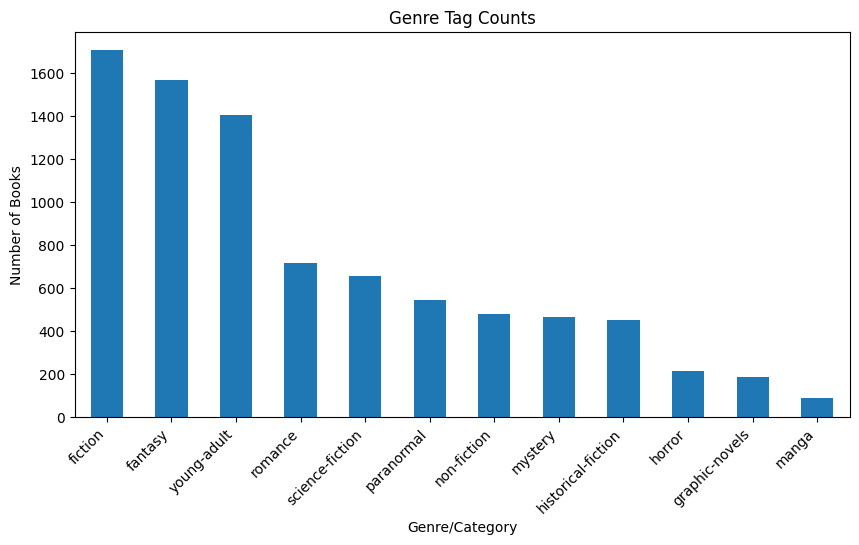

In [57]:
# genre_counts = original_genre_tags['tag_name'].value_counts()
genre_counts = original_genre_tags['tag_name'].value_counts()

plt.figure(figsize=(10, 5))
genre_counts.plot.bar()
plt.title("Genre Tag Counts")
plt.xlabel("Genre/Category")
plt.ylabel("Number of Books")
plt.xticks(rotation=45, ha='right')

plt.show()

In [58]:
genre_counts

tag_name
fiction               1704
fantasy               1567
young-adult           1404
romance                717
science-fiction        655
paranormal             542
non-fiction            479
mystery                464
historical-fiction     451
horror                 215
graphic-novels         185
manga                   87
Name: count, dtype: int64

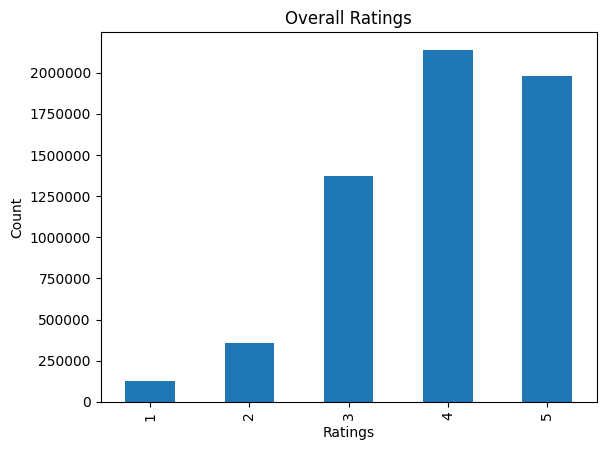

In [59]:
main_df['rating'].value_counts().sort_index().plot.bar(title ="Overall Ratings", xlabel = "Ratings", ylabel = "Count")
plt.ticklabel_format(style='plain', axis='y')

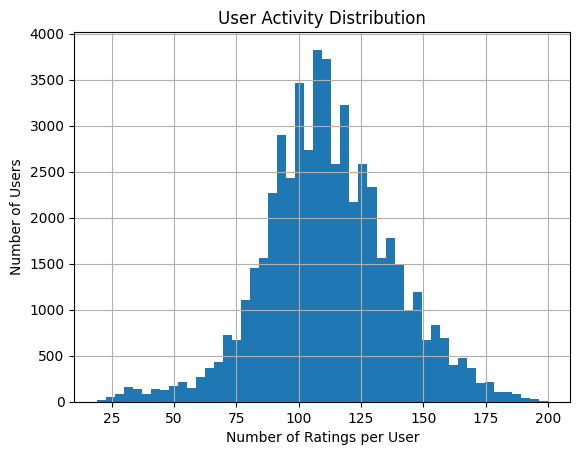

In [60]:
main_df['user_id'].value_counts().hist(bins=50)
plt.xlabel("Number of Ratings per User")
plt.ylabel("Number of Users")
plt.title("User Activity Distribution")

plt.show()

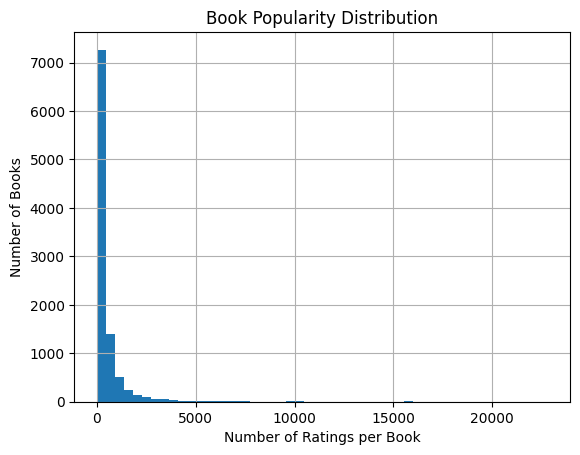

In [62]:
main_df['book_id'].value_counts().hist(bins=50)
plt.xlabel("Number of Ratings per Book")
plt.ylabel("Number of Books")
plt.title("Book Popularity Distribution")

plt.show()


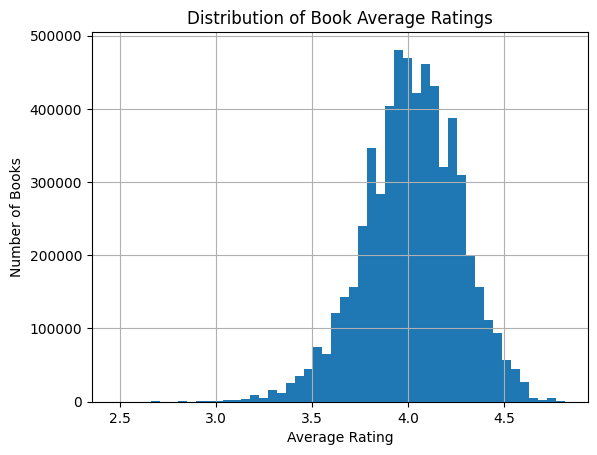

In [63]:
main_df['average_rating'].hist(bins=50)
plt.xlabel("Average Rating")
plt.ylabel("Number of Books")
plt.title("Distribution of Book Average Ratings")
plt.show()

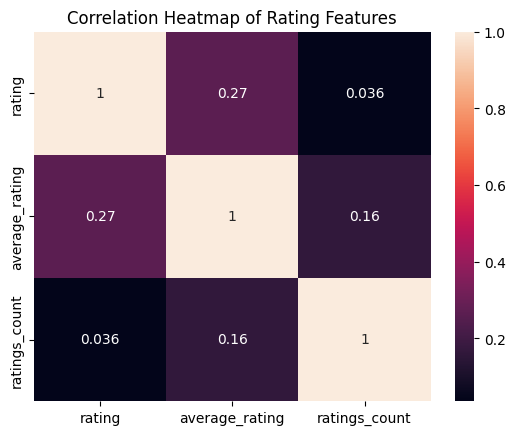

In [65]:
sns.heatmap(main_df[['rating', 'average_rating', 'ratings_count']].corr(), annot=True)
plt.title("Correlation Heatmap of Rating Features")
plt.show()

Prepping data for Apriori and KNN
<ul>
  <li>ratings_df set to only contain "popular books" which are books with at least 50 ratings</li>
  <li>determine active user threshold using iqr</li>
  <li>filter books df for popular books and active user</li>
  
  <li>merge book_tags_df with tags_df to get readable names</li>
  <li>map goodread ids to our main df book_id</li>
  <li>create a df of genre's cleaned and standardized </li>
  <li>use this for apriori</li>
</ul>


In [16]:
user_counts = ratings_df['user_id'].value_counts()
print(len(user_counts))
print(len(user_counts[user_counts >= 48]))

53424
52616


In [17]:
book_counts = ratings_df['book_id'].value_counts()
popular_books = book_counts[book_counts >= 50].index
ratings_df = ratings_df[ratings_df['book_id'].isin(popular_books)]

user_counts = ratings_df['user_id'].value_counts()
Q1 = user_counts.quantile(0.25)
Q3 = user_counts.quantile(0.75)
IQR = Q3 - Q1
threshold =  (Q1 - 1.5 * IQR)
print(threshold)


user_counts = ratings_df['user_id'].value_counts()
active_users = user_counts[user_counts >= threshold].index
ratings_df = ratings_df[ratings_df['user_id'].isin(active_users)]

# main_df updated to just active users and popular books
main_df = ratings_df.merge(books_df, on='book_id', how='left')

48.0


Apriori

In [18]:
# lets recommend books if a user likes a previous book (defined as 4 or higher rating)
top_books = main_df['book_id'].value_counts().head(500).index

liked_books = main_df[
    (main_df['rating'] >= 4) &
    (main_df['book_id'].isin(top_books))
]

user_genres = liked_books.merge(
    original_genre_tags[['book_id', 'tag_name']],
    on='book_id',
    how='inner'
)


In [19]:
genre_data = pd.crosstab(
    user_genres['user_id'],
    user_genres['tag_name']
)
genre_data.head()
genre_data = genre_data.astype(bool)


In [20]:
# run for apriori and association
frequent_itemsets = apriori(genre_data, min_support = 0.1, use_colnames=True)
rules = association_rules(frequent_itemsets, num_itemsets=10, metric="confidence", min_threshold=0.5)

rules = rules[['antecedents', 'consequents', 'support', 'confidence', 'lift']]
rules = rules[(rules['support'] >= 0.1) &
              (rules['confidence'] >= 0.5) &
              (rules['lift'] >= 1.0)]

rules = rules[rules['consequents'].apply(lambda x: len(x) == 1)]
rules = rules[rules['antecedents'].apply(lambda x: len(x) == 2)]
rules = rules.sort_values('confidence', ascending=[False])
rules

,antecedents,consequents,support,confidence,lift
387,"(mystery, paranormal)",(fiction),0.649306,1.000000,1.001070
399,"(mystery, science-fiction)",(fiction),0.795034,1.000000,1.001070
404,"(young-adult, mystery)",(fiction),0.841199,1.000000,1.001070
415,"(romance, non-fiction)",(fiction),0.576977,1.000000,1.001070
411,"(paranormal, non-fiction)",(fiction),0.434741,1.000000,1.001070
...,...,...,...,...,...
675,"(mystery, paranormal)",(non-fiction),0.415962,0.640625,1.010693
108,"(fiction, fantasy)",(non-fiction),0.621443,0.638503,1.007344
373,"(young-adult, fiction)",(horror),0.615088,0.635775,1.012676
664,"(romance, young-adult)",(horror),0.554133,0.633739,1.009431


Lift is too close to 1, will change genre to be more specific maybe

In [21]:
rules['lift'].describe()

count    351.000000
mean       1.037828
std        0.030888
min        1.000889
25%        1.015530
50%        1.027079
75%        1.055067
max        1.178673
Name: lift, dtype: float64

In [22]:
book_tags_named['tag_name'].value_counts().head(50)

tag_name
to-read               9043
currently-reading     2992
favorites             1757
fiction               1704
fantasy               1339
young-adult            923
romance                717
classics               504
books-i-own            482
ya                     481
non-fiction            479
mystery                464
historical-fiction     451
owned                  381
science-fiction        370
paranormal             359
sci-fi                 285
series                 246
urban-fantasy          228
horror                 215
graphic-novels         185
vampires               183
nonfiction             177
contemporary           171
book-club              162
childrens              159
classic                152
comics                 147
favourites             140
history                140
paranormal-romance     139
dystopian              128
dystopia               108
humor                  107
historical             103
chick-lit               97
literature         

In [23]:
genre_tags = book_tags_named.copy()

genre_tags['tag_name'] = genre_tags['tag_name'].str.lower()

genre_tags['tag_name'] = genre_tags['tag_name'].replace({
    'sci-fi': 'science-fiction',
    'ya': 'young-adult',
    'urban-fantasy': 'fantasy',
    'vampires': 'paranormal',
    'classic': 'classics',
    'dystopian': 'dystopia',
})
valid_genres = [
    'fantasy', 'romance', 'mystery', 'science-fiction',
    'young-adult', 'historical-fiction', 'non-fiction',
    'paranormal', 'horror', 'graphic-novels', 'manga', 'dystopia',
    'contemporary', 'thriller', 'humor', 'fiction'
]

genre_tags = genre_tags[
    genre_tags['tag_name'].isin(valid_genres)
]

In [24]:
genre_tags = book_tags_named.copy()

genre_tags['tag_name'] = (
    genre_tags['tag_name']
    .str.lower()
    .str.strip()
)

genre_tags['tag_name'] = genre_tags['tag_name'].replace({
    'sci-fi': 'science-fiction',
    'scifi': 'science-fiction',
    'sci-fi-fantasy': 'science-fiction',

    'ya': 'young-adult',
    'young-adult-fiction': 'young-adult',

    'classic': 'classics',
    'classic-literature': 'classics',
    'literary-classics': 'classics',

    'historical': 'historical-fiction',
    'history-fiction': 'historical-fiction',
    'historical-fantasy': 'historical-fiction',

    'urban-fantasy': 'fantasy',
    'high-fantasy': 'fantasy',
    'epic-fantasy': 'fantasy',

    'vampires': 'paranormal',
    'vampire': 'paranormal',
    'werewolves': 'paranormal',
    'supernatural': 'paranormal',

    'graphic-novel': 'graphic-novels',
    'graphic-novels-comics': 'graphic-novels',
    'comics': 'graphic-novels',
    'comic-books': 'graphic-novels',

    'crime': 'mystery',
    'detective': 'mystery',
    'suspense': 'thriller',

    # Nonfiction variants
    'nonfiction': 'non-fiction',
    'non-fiction': 'non-fiction',
})

valid_genres = [
    'fantasy', 'romance', 'mystery', 'science-fiction',
    'young-adult', 'historical-fiction', 'non-fiction',
    'paranormal', 'horror', 'graphic-novels', 'manga', 'dystopia',
    'contemporary', 'thriller', 'humor', 'fiction'
]

genre_tags = genre_tags[
    genre_tags['tag_name'].isin(valid_genres)
]

In [25]:
print(genre_tags)

        goodreads_book_id  tag_id  count         tag_name  book_id
1                       1   11305  37174          fantasy       27
4                       1   33114  12716      young-adult       27
5                       1   11743   9954          fiction       27
9                       1   32989   4364      young-adult       27
20                      1   26785   1093  science-fiction       27
...                   ...     ...    ...              ...      ...
999313           31538635   11305    639          fantasy     6428
999414           31538647   11305    893          fantasy     7523
999613           32075671   33114   2010      young-adult     9569
999615           32075671    8055   1130     contemporary     9569
999617           32075671   11743    696          fiction     9569

[9758 rows x 5 columns]


In [26]:
top_books = main_df['book_id'].value_counts().head(500).index

liked_books = main_df[
    (main_df['rating'] >= 4) &
    (main_df['book_id'].isin(top_books))
]

user_genres = liked_books.merge(
    genre_tags[['book_id', 'tag_name']],
    on='book_id',
    how='inner'
)
genre_data = pd.crosstab(
    user_genres['user_id'],
    user_genres['tag_name']
)
genre_data.head()
genre_data = genre_data.astype(bool)
frequent_itemsets = apriori(genre_data, min_support = 0.1, use_colnames=True)
rules = association_rules(frequent_itemsets, num_itemsets=10, metric="confidence", min_threshold=0.5)

rules = rules[['antecedents', 'consequents', 'support', 'confidence', 'lift']]
rules = rules[(rules['support'] >= 0.1) &
              (rules['confidence'] >= 0.5) &
              (rules['lift'] >= 1.0)]

rules = rules[rules['consequents'].apply(lambda x: len(x) == 1)]
rules = rules[rules['antecedents'].apply(lambda x: len(x) == 2)]
rules = rules.sort_values('confidence', ascending=[False])
rules
# rerun

,antecedents,consequents,support,confidence,lift
255,"(contemporary, fantasy)",(fiction),0.836447,1.000000,1.001070
1500,"(mystery, non-fiction)",(fiction),0.583103,1.000000,1.001070
333,"(contemporary, humor)",(fiction),0.548274,1.000000,1.001070
338,"(contemporary, mystery)",(fiction),0.776790,1.000000,1.001070
1472,"(paranormal, humor)",(fiction),0.434283,1.000000,1.001070
...,...,...,...,...,...
1475,"(romance, fiction)",(humor),0.556633,0.626991,1.011786
1493,"(young-adult, fiction)",(humor),0.606252,0.626642,1.011223
1048,"(fiction, fantasy)",(humor),0.609057,0.625777,1.009827
2053,"(science-fiction, paranormal)",(humor),0.431211,0.622743,1.004932


Apriori genre's
<ul>
<li>Based on x and y, we are confident in z</li>
</ul>
KNN
<ul>
<li>Predict whether a user will like book X</li>
</ul>

Somehow, pick a book from recommended genre, and predict whether user will like it. If they do, then recommend it

In [27]:
knn_df = main_df[['user_id', 'book_id', 'rating', 'average_rating', 'ratings_count']].copy()
knn_df['liked'] = (knn_df['rating'] >= 4).astype(int)

knn_df.head()

,user_id,book_id,rating,average_rating,ratings_count,liked
0,1,258,5,4.24,263685,1
1,2,4081,4,3.40,19293,1
2,2,260,5,4.13,282623,1
3,2,9296,5,4.09,9563,1
4,2,2318,3,4.00,43937,0


In [28]:
book_genres = pd.crosstab(
    genre_tags['book_id'],
    genre_tags['tag_name']
)

book_genres = book_genres.astype(int).reset_index()

book_genres.head()

tag_name,book_id,contemporary,dystopia,fantasy,fiction,graphic-novels,historical-fiction,horror,humor,manga,mystery,non-fiction,paranormal,romance,science-fiction,thriller,young-adult
0,1,0,1,1,1,0,0,0,0,0,0,0,0,1,4,2,3
1,2,0,0,2,1,0,0,0,0,0,1,0,2,0,1,0,2
2,3,1,0,2,1,0,0,0,0,0,0,0,5,0,1,0,3
3,4,0,0,0,1,0,2,0,0,0,0,0,0,0,0,0,2
4,5,0,0,0,1,0,2,0,0,0,0,0,0,1,0,0,0


In [29]:
knn_df = knn_df.merge(
    book_genres,
    on='book_id',
    how='left'
)

knn_df = knn_df.fillna(0)

knn_df.shape
knn_df.head()

,user_id,book_id,rating,average_rating,ratings_count,liked,contemporary,dystopia,fantasy,fiction,...,horror,humor,manga,mystery,non-fiction,paranormal,romance,science-fiction,thriller,young-adult
0,1,258,5,4.24,263685,1,0.0,0.0,1.0,1.0,...,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0
1,2,4081,4,3.40,19293,1,0.0,0.0,0.0,1.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2,2,260,5,4.13,282623,1,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,2.0,0.0,0.0,0.0,0.0,0.0
3,2,9296,5,4.09,9563,1,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4,2,2318,3,4.00,43937,0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0


x = features (the given parameters)

y = target (what we are trying to predict)

In [30]:
# print(type(book_genres))
features = [
    'average_rating',
    'ratings_count'
] + list(book_genres.columns.drop('book_id'))
print(features)


['average_rating', 'ratings_count', 'contemporary', 'dystopia', 'fantasy', 'fiction', 'graphic-novels', 'historical-fiction', 'horror', 'humor', 'manga', 'mystery', 'non-fiction', 'paranormal', 'romance', 'science-fiction', 'thriller', 'young-adult']


In [31]:
knn_sample = knn_df.sample(
    n=100000,
    random_state=42
)

X = knn_sample[features].values
y = knn_sample['liked'].values
print(X.shape)
print(y.shape)

(100000, 18)
(100000,)


In [32]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [33]:
knn_clf = Pipeline([
        ("scaler", StandardScaler()),
        ("knn", KNeighborsClassifier(n_neighbors=4))
    ])

knn_clf.fit(X_train, y_train)
y_pred = knn_clf.predict(X_test)


In [34]:
knn_acc = accuracy_score(y_test, y_pred)
print("KNN Accuracy:", knn_acc)

confmat_knn = confusion_matrix(y_test, y_pred)
print("KNN Confusion Matrix:\n", confmat_knn)

KNN Accuracy: 0.58645
KNN Confusion Matrix:
 [[2747 3451]
 [4820 8982]]


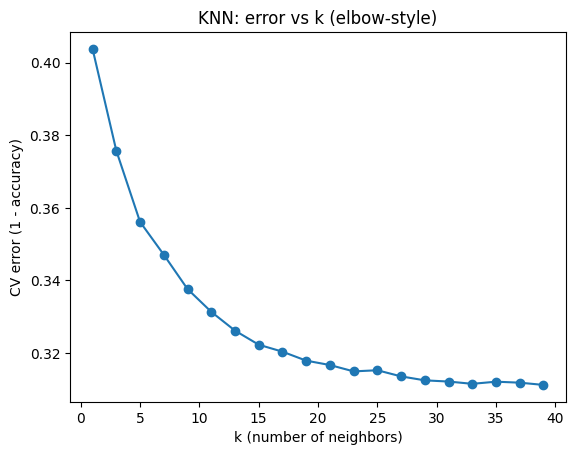

In [46]:
k_values = range(1, 41, 2)  # odd k's
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

errors = []
for k in k_values:
    model = Pipeline([
        ("scaler", StandardScaler()),
        ("knn", KNeighborsClassifier(n_neighbors=k))
    ])
    acc = cross_val_score(model, X, y, cv=cv, scoring="accuracy").mean()
    errors.append(1 - acc)

plt.plot(list(k_values), errors, marker="o")
plt.xlabel("k (number of neighbors)")
plt.ylabel("CV error (1 - accuracy)")
plt.title("KNN: error vs k (elbow-style)")
plt.show()

In [47]:
knn2 = Pipeline([
    ('scaler', StandardScaler()),
    ('knn', KNeighborsClassifier(n_neighbors=23))
])

knn2.fit(X_train, y_train)

final_pred = knn2.predict(X_test)

knn_acc = accuracy_score(y_test, final_pred)
print("KNN Accuracy:", knn_acc)

confmat_knn = confusion_matrix(y_test, final_pred)
print("KNN Confusion Matrix:\n", confmat_knn)

KNN Accuracy: 0.6865
KNN Confusion Matrix:
 [[  968  5230]
 [ 1040 12762]]


In [37]:
book_genres

tag_name,book_id,contemporary,dystopia,fantasy,fiction,graphic-novels,historical-fiction,horror,humor,manga,mystery,non-fiction,paranormal,romance,science-fiction,thriller,young-adult
0,1,0,1,1,1,0,0,0,0,0,0,0,0,1,4,2,3
1,2,0,0,2,1,0,0,0,0,0,1,0,2,0,1,0,2
2,3,1,0,2,1,0,0,0,0,0,0,0,5,0,1,0,3
3,4,0,0,0,1,0,2,0,0,0,0,0,0,0,0,0,2
4,5,0,0,0,1,0,2,0,0,0,0,0,0,1,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4898,9992,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0
4899,9993,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0
4900,9996,0,0,2,0,0,0,0,0,0,0,0,0,0,0,0,0
4901,9998,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0


### Hybrid System

1. **Create a `book_info` table**
   - Stores readable book information such as `book_id`, title, author, average rating, rating count, and genre/category labels.
   - This table is used later to display recommendation results.

2. **Create `knn_conslidate`**
   - Creates one row per book with the same feature columns used by the KNN model.
   - These rows are the books that can potentially be recommended.

3. **Run the hybrid Apriori → KNN system**

   For a selected user:

   1. Get the user’s rating history.
   2. Create a list of books the user liked, defined as books rated 4 or higher.
   3. Look up the genre/category tags for those liked books.
   4. Use the liked-book genre tags as the user’s genre basket.
   5. Apply Apriori rules to the genre basket to identify a recommended related genre/category (from the previously ran apriori).
   6. Filter the book database to books that match the Apriori-recommended genre/category.
   7. Remove books the user has already rated.
   8. Run the trained KNN classifier on the remaining candidate books.
   9. Return a recommendation DataFrame containing books ranked by predicted probability of being liked.

In [38]:
book_info = (
    main_df[['book_id', 'title', 'authors', 'average_rating', 'ratings_count']]
    .drop_duplicates('book_id')
    .reset_index(drop=True)
)
genres_by_book = (
    genre_tags[['book_id', 'tag_name']]
    .drop_duplicates()
    .groupby('book_id')['tag_name']
    .apply(lambda x: ', '.join(sorted(set(x))))
    .reset_index(name='genres')
)

book_info = book_info.merge(
    genres_by_book,
    on='book_id',
    how='left'
)

# print("Book lookup shape:", book_info.shape)
# book_info

# several books with missing genres due to the threshold of needing 500 counts of a single tag. i tried reducing this earlier, but it ended up being worse.
# for now, impute missing genre's with "Unknown"
book_info['genres'] = book_info['genres'].fillna('Unknown')
book_info

,book_id,title,authors,average_rating,ratings_count,genres
0,258,The Shadow of the Wind (The Cemetery of Forgot...,"Carlos Ruiz Zafón, Lucia Graves",4.24,263685,"fantasy, fiction, historical-fiction, mystery"
1,4081,I am Charlotte Simmons,Tom Wolfe,3.40,19293,fiction
2,260,How to Win Friends and Influence People,Dale Carnegie,4.13,282623,non-fiction
3,9296,The Drama of the Gifted Child: The Search for ...,"Alice Miller, Ruth Ward",4.09,9563,Unknown
4,2318,The Millionaire Next Door: The Surprising Secr...,"Thomas J. Stanley, William D. Danko",4.00,43937,non-fiction
...,...,...,...,...,...,...
9986,3885,Born a Crime: Stories From a South African Chi...,Trevor Noah,4.49,42573,non-fiction
9987,9569,The Hate U Give,Angie Thomas,4.62,32610,"contemporary, fiction, young-adult"
9988,9580,Egomaniac,Vi Keeland,4.34,11310,Unknown
9989,8892,Wait for It,Mariana Zapata,4.22,18371,Unknown


In [39]:
knn_consolidate = (
    knn_df[['book_id'] + features]
    .drop_duplicates('book_id')
    .copy()
)

print("Book candidates shape:", knn_consolidate.shape)
knn_consolidate

Book candidates shape: (9991, 19)


,book_id,average_rating,ratings_count,contemporary,dystopia,fantasy,fiction,graphic-novels,historical-fiction,horror,humor,manga,mystery,non-fiction,paranormal,romance,science-fiction,thriller,young-adult
0,258,4.24,263685,0.0,0.0,1.0,1.0,0.0,2.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0
1,4081,3.40,19293,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2,260,4.13,282623,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,2.0,0.0,0.0,0.0,0.0,0.0
3,9296,4.09,9563,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4,2318,4.00,43937,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
5806589,3885,4.49,42573,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,2.0,0.0,0.0,0.0,0.0,0.0
5808278,9569,4.62,32610,1.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0
5808395,9580,4.34,11310,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
5829271,8892,4.22,18371,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


Apriori

In [40]:
# def get_user_liked_genres(user_id):

#     liked_books_user = main_df[
#         (main_df['user_id'] == user_id) &
#         (main_df['rating'] >= 4)
#     ][['book_id']].drop_duplicates()

#     liked_genres_user = liked_books_user.merge(
#         genre_tags[['book_id', 'tag_name']],
#         on='book_id',
#         how='inner'
#     )

#     user_genres = set(liked_genres_user['tag_name'])

#     return user_genres

ignore_genres = {'fiction'}

def get_user_liked_genres(user_id, min_genre_count=10):

    liked_books_user = main_df[
        (main_df['user_id'] == user_id) &
        (main_df['rating'] >= 4)
    ][['book_id']].drop_duplicates()

    liked_genres_user = liked_books_user.merge(
        genre_tags[['book_id', 'tag_name']],
        on='book_id',
        how='inner'
    )

    genre_counts = liked_genres_user['tag_name'].value_counts()

    liked_genres = set(
        genre_counts[genre_counts >= min_genre_count].index
    )

    return liked_genres

# create a function that gets recommended genres. take in user id, max number of genre recommendations, and a lift threshold

def recommend_genres_from_apriori(user_id, num_of_genres, min_lift=1.0):

    user_genres = get_user_liked_genres(user_id)
    #user_id = 1, user_genres = {fantasy, romance, fiction}
    # filter through all of apriori results, look for any combinations for these antecedents

    # rules >= minimum threshold &&
    # for every antecedent, check to see if it is a subset of user genre
    matching_rules = rules[
        (rules['lift'] >= min_lift) &
        (rules['antecedents'].apply(lambda x: x.issubset(user_genres)))
    ].copy()

    # basecase
    if matching_rules.empty:
        return []

    matching_rules = matching_rules.sort_values(
        ['confidence', 'lift', 'support'],
        ascending=False
    )

    recommended_genres = []
    # for all the consequents (consequents), push it into recommended_genres
    # for consequent in matching_rules['consequents']:
    #     genre = list(consequent)[0]
    #     recommended_genres.append(genre)
    for consequent in matching_rules['consequents']:
        genre = list(consequent)[0]

        if genre not in ignore_genres:
            recommended_genres.append(genre)


    recommended_genres = list(dict.fromkeys(recommended_genres))

    # recommend only the first n genres
    return recommended_genres[:num_of_genres]


In [41]:
def hybrid_apriori_knn_recommend(user_id, top_genres=3, min_lift=1.0):

    user_liked_genres = get_user_liked_genres(user_id)

    apriori_genres = recommend_genres_from_apriori(
        user_id=user_id,
        num_of_genres=top_genres,
        min_lift=min_lift,
    )

    print("User ID:", user_id)
    print("User liked genres:", sorted(user_liked_genres))
    print("Apriori recommended genres:", apriori_genres)

    # base case
    if len(apriori_genres) == 0:
        print("No matching Apriori rule found for this user.")
        return pd.DataFrame()

    possible_book_ids = genre_tags[genre_tags['tag_name'].isin(apriori_genres)]['book_id'].unique()

    #need to make sure our list of potential books do not include books that the user has already read

    already_rated = set(
        main_df[main_df['user_id'] == user_id]['book_id']
    )

    potential_books = knn_consolidate[
        (knn_consolidate['book_id'].isin(possible_book_ids)) &
        (~knn_consolidate['book_id'].isin(already_rated))
    ].copy()

    if potential_books.empty:
        print("No potential books found after Apriori filtering.")
        return pd.DataFrame()

    X_potential = potential_books[features].values

    # potential_books['predicted_like_probability'] = knn2.predict_proba(X_potential)[:, 1]
    potential_books['predicted_like'] = knn2.predict(X_potential)
    potential_books = potential_books[
        potential_books['predicted_like'] == 1
    ].copy()

    recommendations = potential_books.merge(
        book_info,
        on='book_id',
        how='left',
        suffixes=('_feature', '')
    )

    recommendations = (
        recommendations[
            [
                'book_id',
                'title',
                'authors',
                'genres',
                'average_rating',
                'ratings_count',
                'predicted_like'
            ]
        ]
        .sort_values(
            ['predicted_like', 'average_rating'],
            ascending=False
        )
    )

    return recommendations

In [42]:
print("Hybrid Apriori + KNN Recommendations:")

hybrid_recommendations = hybrid_apriori_knn_recommend(
    user_id=6,
    top_genres=3,
    min_lift=1.0
)

hybrid_recommendations

Hybrid Apriori + KNN Recommendations:
User ID: 6
User liked genres: ['fiction', 'non-fiction']
Apriori recommended genres: ['fantasy', 'young-adult', 'historical-fiction']


,book_id,title,authors,genres,average_rating,ratings_count,predicted_like
1617,862,"Words of Radiance (The Stormlight Archive, #2)",Brandon Sanderson,"fantasy, fiction",4.77,73572,1
1380,562,"The Way of Kings (The Stormlight Archive, #1)",Brandon Sanderson,"fantasy, fiction",4.64,144822,1
1548,2149,A Song of Ice and Fire (A Song of Ice and Fire...,George R.R. Martin,fantasy,4.63,28654,1
1976,3241,"Crooked Kingdom (Six of Crows, #2)",Leigh Bardugo,"fantasy, young-adult",4.62,44289,1
2054,9569,The Hate U Give,Angie Thomas,"contemporary, fiction, young-adult",4.62,32610,1
...,...,...,...,...,...,...,...
405,3406,The Dante Club,Matthew Pearl,"fiction, historical-fiction, mystery",3.38,31035,1
432,8142,"Forest Mage (Soldier Son, #2)",Robin Hobb,fantasy,3.35,11953,1
1129,4992,"A Lion Among Men (The Wicked Years, #3)","Gregory Maguire, Douglas Smith","fantasy, fiction",3.29,21794,1
81,4317,Mirror Mirror,Gregory Maguire,"fantasy, fiction",3.27,26307,1


Using predict.proba

https://scikit-learn.org/stable/modules/generated/sklearn.neighbors.KNeighborsClassifier.html#sklearn.neighbors.KNeighborsClassifier.predict_proba

In [43]:
def hybrid_apriori_knn_recommend(user_id, top_genres=3, min_lift=1.0):

    user_liked_genres = get_user_liked_genres(user_id)

    apriori_genres = recommend_genres_from_apriori(
        user_id=user_id,
        num_of_genres=top_genres,
        min_lift=min_lift,
    )

    print("User ID:", user_id)
    print("User liked genres:", sorted(user_liked_genres))
    print("Apriori recommended genres:", apriori_genres)

    # base case
    if len(apriori_genres) == 0:
        print("No matching Apriori rule found for this user.")
        return pd.DataFrame()

    possible_book_ids = genre_tags[genre_tags['tag_name'].isin(apriori_genres)]['book_id'].unique()

    #need to make sure our list of potential books do not include books that the user has already read

    already_rated = set(
        main_df[main_df['user_id'] == user_id]['book_id']
    )

    potential_books = knn_consolidate[
        (knn_consolidate['book_id'].isin(possible_book_ids)) &
        (~knn_consolidate['book_id'].isin(already_rated))
    ].copy()

    if potential_books.empty:
        print("No potential books found after Apriori filtering.")
        return pd.DataFrame()

    X_potential = potential_books[features].values

    # potential_books['predicted_like_probability'] = knn2.predict_proba(X_potential)[:, 1]
    potential_books['predicted_like'] = knn2.predict(X_potential)
    potential_books['predicted_like_probability'] = knn2.predict_proba(X_potential)[:, 1]
    potential_books = potential_books[
        potential_books['predicted_like'] == 1
    ].copy()

    recommendations = potential_books.merge(
        book_info,
        on='book_id',
        how='left',
        suffixes=('_feature', '')
    )

    recommendations = (
        recommendations[
            [
                'book_id',
                'title',
                'authors',
                'genres',
                'average_rating',
                'ratings_count',
                'predicted_like',
                'predicted_like_probability'
            ]
        ]
        .sort_values(
            ['predicted_like_probability'],
            ascending=False
        )
    )

    return recommendations

In [44]:
print("Hybrid Apriori + KNN Recommendations:")

hybrid_recommendations = hybrid_apriori_knn_recommend(
    user_id=6,
    top_genres=3,
    min_lift=1.0
)

hybrid_recommendations

Hybrid Apriori + KNN Recommendations:
User ID: 6
User liked genres: ['fiction', 'non-fiction']
Apriori recommended genres: ['fantasy', 'young-adult', 'historical-fiction']


,book_id,title,authors,genres,average_rating,ratings_count,predicted_like,predicted_like_probability
1056,4798,"Genghis: Birth of an Empire (Conqueror, #1)",Conn Iggulden,historical-fiction,4.34,16498,1,1.000000
1610,1654,"Cold Days (The Dresden Files, #14)",Jim Butcher,fantasy,4.51,57779,1,1.000000
1617,862,"Words of Radiance (The Stormlight Archive, #2)",Brandon Sanderson,"fantasy, fiction",4.77,73572,1,1.000000
1849,9274,"The Pagan Lord (The Saxon Stories, #7)",Bernard Cornwell,historical-fiction,4.34,8218,1,1.000000
1661,1353,"Winter (The Lunar Chronicles, #4)",Marissa Meyer,"dystopia, fantasy, fiction, romance, science-f...",4.49,100464,1,1.000000
...,...,...,...,...,...,...,...,...
998,6855,"The Innocent Mage (Kingmaker, Kingbreaker, #1)",Karen Miller,fantasy,3.65,15419,1,0.521739
1007,1850,"Wake (Wake, #1)",Lisa McMann,young-adult,3.75,69046,1,0.521739
54,361,Oliver Twist,"Charles Dickens, George Cruikshank, Philip Horne","fiction, historical-fiction",3.85,230181,1,0.521739
1061,3626,The Adoration of Jenna Fox (Jenna Fox Chronicl...,Mary E. Pearson,"science-fiction, young-adult",3.70,36754,1,0.521739


Show the top 2 recommendations

In [45]:
print(f"You may like: {hybrid_recommendations.iloc[0]['title']} \nYou may also like: {hybrid_recommendations.iloc[1]['title']}")


You may like: Genghis: Birth of an Empire (Conqueror, #1) 
You may also like: Cold Days (The Dresden Files, #14)
